# Exploratory Data Analysis

### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)

### Load the Datasets

In [2]:
df_milano_train = pd.read_csv('../data/raw/dati_milano_train.csv', sep=';')
df_milano_test = pd.read_csv('../data/raw/dati_milano_test.csv', sep=';')
df_berlin = pd.read_excel('../data/raw/dati_berlino.xlsx')

In [3]:
print(f"Dataset 1 (Berlin):\n\t {df_berlin.shape[0]} rows and {df_berlin.shape[1]} columns\n")
print(f"Dataset 2 (Milan - train dataset):\n\t {df_milano_train.shape[0]} rows and {df_milano_train.shape[1]} columns\n")
print(f"Dataset 2 (Milan - test dataset):\n\t {df_milano_test.shape[0]} rows and {df_milano_test.shape[1]} columns\n")

Dataset 1 (Berlin):
	 441 rows and 32 columns

Dataset 2 (Milan - train dataset):
	 405 rows and 32 columns

Dataset 2 (Milan - test dataset):
	 50 rows and 32 columns



In [4]:
df_berlin.convert_dtypes().info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 441 entries, 0 to 440
Data columns (total 32 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          441 non-null    string 
 1   gender                      440 non-null    string 
 2   age                         441 non-null    Int64  
 3   subject_height              441 non-null    Int64  
 4   weight                      441 non-null    Float64
 5   BMI                         441 non-null    Float64
 6   height_of_fall              441 non-null    Float64
 7   mgh                         441 non-null    Float64
 8   HEAD                        441 non-null    Int64  
 9   Skull                       441 non-null    Int64  
 10  FacialSkeleton              441 non-null    Int64  
 11  Cerebrum                    441 non-null    Int64  
 12  Cerebellum                  441 non-null    Int64  
 13  BrainStem                   441 non

In [5]:
df_milano_train.convert_dtypes().info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 405 entries, 0 to 404
Data columns (total 32 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Casi                       405 non-null    Int64 
 1   Sesso                      405 non-null    string
 2   Età                        405 non-null    Int64 
 3   Altezza_soggetto           405 non-null    Int64 
 4   Peso                       405 non-null    string
 5   BMI                        405 non-null    string
 6   Altezza_di_precipitazione  405 non-null    Int64 
 7   mgh                        405 non-null    string
 8   TESTA                      405 non-null    Int64 
 9   Neurocranio                405 non-null    Int64 
 10  Splancnocranio             405 non-null    Int64 
 11  Telencefalo                405 non-null    Int64 
 12  Cervelletto                405 non-null    Int64 
 13  TroncoEncefalico           405 non-null    Int64 
 14  TORACE    

In [6]:
df_milano_test.convert_dtypes().info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 32 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Casi                       50 non-null     Int64 
 1   Sesso                      50 non-null     string
 2   Età                        50 non-null     Int64 
 3   Altezza_soggetto           50 non-null     Int64 
 4   Peso                       50 non-null     string
 5   BMI                        50 non-null     string
 6   Altezza_di_precipitazione  50 non-null     Int64 
 7   mgh                        50 non-null     string
 8   TESTA                      50 non-null     Int64 
 9   Neurocranio                50 non-null     Int64 
 10  Splancnocranio             50 non-null     Int64 
 11  Telencefalo                50 non-null     Int64 
 12  Cervelletto                50 non-null     Int64 
 13  TroncoEncefalico           50 non-null     Int64 
 14  TORACE      

#### Column Mapping

In [7]:
column_mapping_berlin = {
    'ID': 'case_id', 
    'gender': 'sex', 
    'age': 'age', 
    'subject_height': 'subject_height', 
    'weight': 'weight', 
    'BMI': 'bmi',
    'height_of_fall': 'height_of_fall_m', 
    'mgh': 'mgh', 
    'HEAD': 'head', 
    'Skull': 'neurocranium',
    'FacialSkeleton': 'viscerocranium', 
    'Cerebrum': 'telencephalon', 
    'Cerebellum': 'cerebellum', 
    'BrainStem': 'brainstem',
    'THORAX': 'thorax', 
    'Lungs': 'lungs', 
    'TracheaBronchi': 'larynx_bronchus', 
    'Heart': 'heart', 
    'ThoracicAorta': 'aorta_thoracic',
    'Diaphragm': 'diaphragm', 
    'ABDOMEN': 'abdomen', 
    'Liver': 'liver', 
    'Spleen': 'spleen', 
    'AbdominalAorta': 'aorta_abdominal', 
    'Kidneys': 'kidneys',
    'Mesentery': 'mesentery', 
    'SKELETON': 'skeleton', 
    'CervicalSpine': 'cervical_spine', 
    'ThoracicSpine': 'thoracic_spine',
    'LumbarSpine': 'lumbar_spine', 
    'Pelvis': 'pelvis', 
    'SternumClavicleRibsComplex': 'skull_cervical_complex'
}

column_mapping_milan_train={
    'Casi': 'case_id', 
    'Sesso': 'sex', 
    'Età': 'age', 
    'Altezza_soggetto': 'subject_height', 
    'Peso': 'weight', 
    'BMI': 'bmi',
    'Altezza_di_precipitazione': 'height_of_fall_m', 
    'mgh': 'mgh', 
    'TESTA': 'head', 
    'Neurocranio': 'neurocranium',
    'Splancnocranio': 'viscerocranium', 
    'Telencefalo': 'telencephalon', 
    'Cervelletto': 'cerebellum', 
    'TroncoEncefalico': 'brainstem',
    'TORACE': 'thorax', 
    'Polmoni': 'lungs', 
    'Tracheabronchi': 'larynx_bronchus', 
    'Cuore': 'heart', 
    'AortaT': 'aorta_thoracic', 
    'Diaframma': 'diaphragm',
    'ADDOME': 'abdomen', 
    'Fegato': 'liver', 
    'Milza': 'spleen', 
    'AortaAdd': 'aorta_abdominal', 
    'Reni': 'kidneys', 
    'Mesentere': 'mesentery',
    'SCHELETRO': 'skeleton', 
    'RachideCervicale': 'cervical_spine', 
    'RachideToracico': 'thoracic_spine', 
    'RachideLombare': 'lumbar_spine',
    'Bacino': 'pelvis', 
    'ComplessoSCC': 'skull_cervical_complex'
}

column_mapping_milan_test={
    'Casi': 'case_id', 
    'Sesso': 'sex', 
    'Età': 'age', 
    'Altezza_soggetto': 'subject_height', 
    'Peso': 'weight', 
    'BMI': 'bmi',
    'Altezza_di_precipitazione': 'height_of_fall_m', 
    'mgh': 'mgh', 
    'TESTA': 'head', 
    'Neurocranio': 'neurocranium',
    'Splancnocranio': 'viscerocranium', 
    'Telencefalo': 'telencephalon', 
    'Cervelletto': 'cerebellum', 
    'TroncoEncefalico': 'brainstem',
    'TORACE': 'thorax', 
    'Polmoni': 'lungs', 
    'TacheaBronchi': 'larynx_bronchus', 
    'Cuore': 'heart', 
    'Aorta': 'aorta_thoracic', 
    'Diaframma': 'diaphragm',
    'ADDOME': 'abdomen', 
    'Fegato': 'liver', 
    'Milza': 'spleen', 
    'Aortaadd': 'aorta_abdominal', 
    'Reni': 'kidneys', 
    'Mesentere': 'mesentery',
    'SCHELETRO': 'skeleton', 
    'RachideCervicale': 'cervical_spine', 
    'RachideToracico': 'thoracic_spine', 
    'RachideLombare': 'lumbar_spine',
    'Bacino': 'pelvis', 
    'ComplessoSCC': 'skull_cervical_complex'
}

#### Schema Definition

In [8]:
schema_berlin={
    "case_id": "Int64",
    "sex": "string",
    "age": "Int64",
    "subject_height": "float64",
    "weight": "float64",
    "bmi": "float64",
    "height_of_fall_m": "float64",
    "mgh": "float64",
    "head": "Int64",
    "neurocranium": "Int64",
    "viscerocranium": "Int64",
    "telencephalon": "Int64",
    "cerebellum": "Int64",
    "brainstem": "Int64",
    "thorax": "Int64",
    "lungs": "Int64",
    "larynx_bronchus": "Int64",
    "heart": "Int64",
    "aorta_thoracic": "Int64",
    "diaphragm": "Int64",
    "abdomen": "Int64",
    "liver": "Int64",
    "spleen": "Int64",
    "aorta_abdominal": "Int64",
    "kidneys": "Int64",
    "mesentery": "Int64",
    "skeleton": "Int64",
    "cervical_spine": "Int64",
    "thoracic_spine": "Int64",
    "lumbar_spine": "Int64",
    "pelvis": "Int64",
    "skull_cervical_complex": "Int64"
}

schema_milan={
    "case_id": "Int64",
    "sex": "string",
    "age": "Int64",
    "subject_height": "float64",
    "weight": "float64",
    "bmi": "float64",
    "height_of_fall_m": "float64",
    "mgh": "float64",
    "head": "Int64",
    "neurocranium": "Int64",
    "viscerocranium": "Int64",
    "telencephalon": "Int64",
    "cerebellum": "Int64",
    "brainstem": "Int64",
    "thorax": "Int64",
    "lungs": "Int64",
    "larynx_bronchus": "Int64",
    "heart": "Int64",
    "aorta_thoracic": "Int64",
    "diaphragm": "Int64",
    "abdomen": "Int64",
    "liver": "Int64",
    "spleen": "Int64",
    "aorta_abdominal": "Int64",
    "kidneys": "Int64",
    "mesentery": "Int64",
    "skeleton": "Int64",
    "cervical_spine": "Int64",
    "thoracic_spine": "Int64",
    "lumbar_spine": "Int64",
    "pelvis": "Int64",
    "skull_cervical_complex": "Int64"
}

#### Create reusable function for histogram plots

In [9]:
def create_histogram_plots(df, columns, dataset_name):
    """
    Given the dataframe create histogram plots for each column in the columns list. 
    It creates a maximum of six histogram plots.

    Args:
        - df (DataFrame): pandas dataframe in input
        - columns (list): list of columns in the DataFrame used for the histogram plots. 
        At most six column names can be passed as argument
        - dataset_name (string): dataset name that will be printed on the plots 

    """
    fig, axes = plt.subplots(3, 2, figsize=(15, 18))
    axes = axes.flatten()
    
    for i, col in enumerate(columns):
        axes[i].hist(df[col], 
                    bins=15, 
                    alpha=0.8, 
                    color='steelblue', 
                    edgecolor='white', 
                    linewidth=0.7)
        
        axes[i].grid(axis='y', linestyle='--', alpha=0.4, color='gray')
        axes[i].set_title(f'{col.replace("_", " ").title()} Distribution - {dataset_name}', 
                         fontsize=12, fontweight='bold', pad=15)
        axes[i].set_xlabel(col.upper(), fontsize=11, fontweight='medium')
        axes[i].set_ylabel('Frequency', fontsize=11, fontweight='medium')
        axes[i].spines['top'].set_visible(False)
        axes[i].spines['right'].set_visible(False)
        axes[i].tick_params(axis='both', which='major', labelsize=10)
    
    plt.tight_layout()
    plt.show()

# Define columns for histogram plots 
hist_columns = ['age', 'subject_height', 'weight', 'height_of_fall_m', 'bmi', 'mgh']

## Berlin Data Analysis

In this section, the dataset with the records from Berlin will be analyzed, and in particular:
- the number of null values if any
- the value distributions for both numerical and categorical columns

In the data:
- **bmi** stands for: body mass index - ratio of weight to height (kg/m²)
- **mgh** stands for: gravitational potential energy - mass(kg)x gravitational acceleration (≈ 9.8 m/s² on Earth)xheight above a reference point (m)
- the fields: head, thorax, abdomen and skeleton, represent the cumulative sum of the injuries severity per body region. Severity is measured on a scale from 0 to 4.


In [10]:
# Rename columns and enforce schema
df_berlin=df_berlin.rename(columns=column_mapping_berlin)
df_berlin=df_berlin.astype(dtype=schema_berlin)

In [ ]:
df_berlin.head()

In [12]:
df_berlin.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 441 entries, 0 to 440
Data columns (total 32 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   case_id                 441 non-null    Int64  
 1   sex                     440 non-null    string 
 2   age                     441 non-null    Int64  
 3   subject_height          441 non-null    float64
 4   weight                  441 non-null    float64
 5   bmi                     441 non-null    float64
 6   height_of_fall_m        441 non-null    float64
 7   mgh                     441 non-null    float64
 8   head                    441 non-null    Int64  
 9   neurocranium            441 non-null    Int64  
 10  viscerocranium          441 non-null    Int64  
 11  telencephalon           441 non-null    Int64  
 12  cerebellum              441 non-null    Int64  
 13  brainstem               441 non-null    Int64  
 14  thorax                  441 non-null    In

The null values are contained in the following columns:
- sex: 1 
- spleen: 2

The records with null value for the spleen will be dropped. 

In [13]:
df_berlin_without_null=df_berlin.dropna(subset=['spleen'])
print(f"Number of records: {df_berlin_without_null.shape[0]}")

Number of records: 439


In [14]:
print("Column Name - N. of Unique Values:")
df_berlin_without_null.nunique()

Column Name - N. of Unique Values:


case_id                   439
sex                         2
age                        81
subject_height             52
weight                     79
bmi                       374
height_of_fall_m           48
mgh                       300
head                       21
neurocranium                5
viscerocranium              5
telencephalon               5
cerebellum                  5
brainstem                   5
thorax                     21
lungs                       5
larynx_bronchus             5
heart                       5
aorta_thoracic              5
diaphragm                   5
abdomen                    21
liver                       5
spleen                      5
aorta_abdominal             5
kidneys                     5
mesentery                   5
skeleton                   19
cervical_spine              5
thoracic_spine              5
lumbar_spine                5
pelvis                      5
skull_cervical_complex      5
dtype: int64

In [15]:
df_berlin_without_null[[ 'age', 'subject_height', 
       'height_of_fall_m', 'bmi', 'mgh']].describe().round(2).drop('count')

,age,subject_height,height_of_fall_m,bmi,mgh
mean,49.44,170.08,22.17,25.65,16365.00
std,19.94,10.42,15.76,4.56,12440.47
min,14.0,136.00,3.00,14.69,1323.00
25%,34.0,163.00,12.00,22.72,7761.60
50%,48.0,170.00,15.00,25.15,12142.20
75%,64.0,177.00,29.25,28.39,21168.00
max,95.0,198.00,117.00,42.52,73382.40


In [ ]:
categorical_columns=['sex', 'neurocranium', 'viscerocranium',
       'telencephalon', 'cerebellum', 'brainstem', 'lungs',
       'larynx_bronchus', 'heart', 'aorta_thoracic', 'diaphragm',
       'liver', 'spleen', 'aorta_abdominal', 'kidneys', 'mesentery',
    'cervical_spine', 'thoracic_spine', 'lumbar_spine',
       'pelvis', 'skull_cervical_complex']

for col in categorical_columns:
    print(f"\nColumn: {col}")
    print(f"Number of distinct values: {df_berlin_without_null[col].value_counts().count()}")
    print(f"List of values and the number of times they appear in the dataset:")
    
    df_value_counts = df_berlin_without_null[col].value_counts().reset_index()
    df_value_counts.columns = [col, 'count']
    
    display(
            df_value_counts.style.set_table_attributes(
                'style="display:block; max-height:300px; overflow-y:scroll;"'
            )
        )

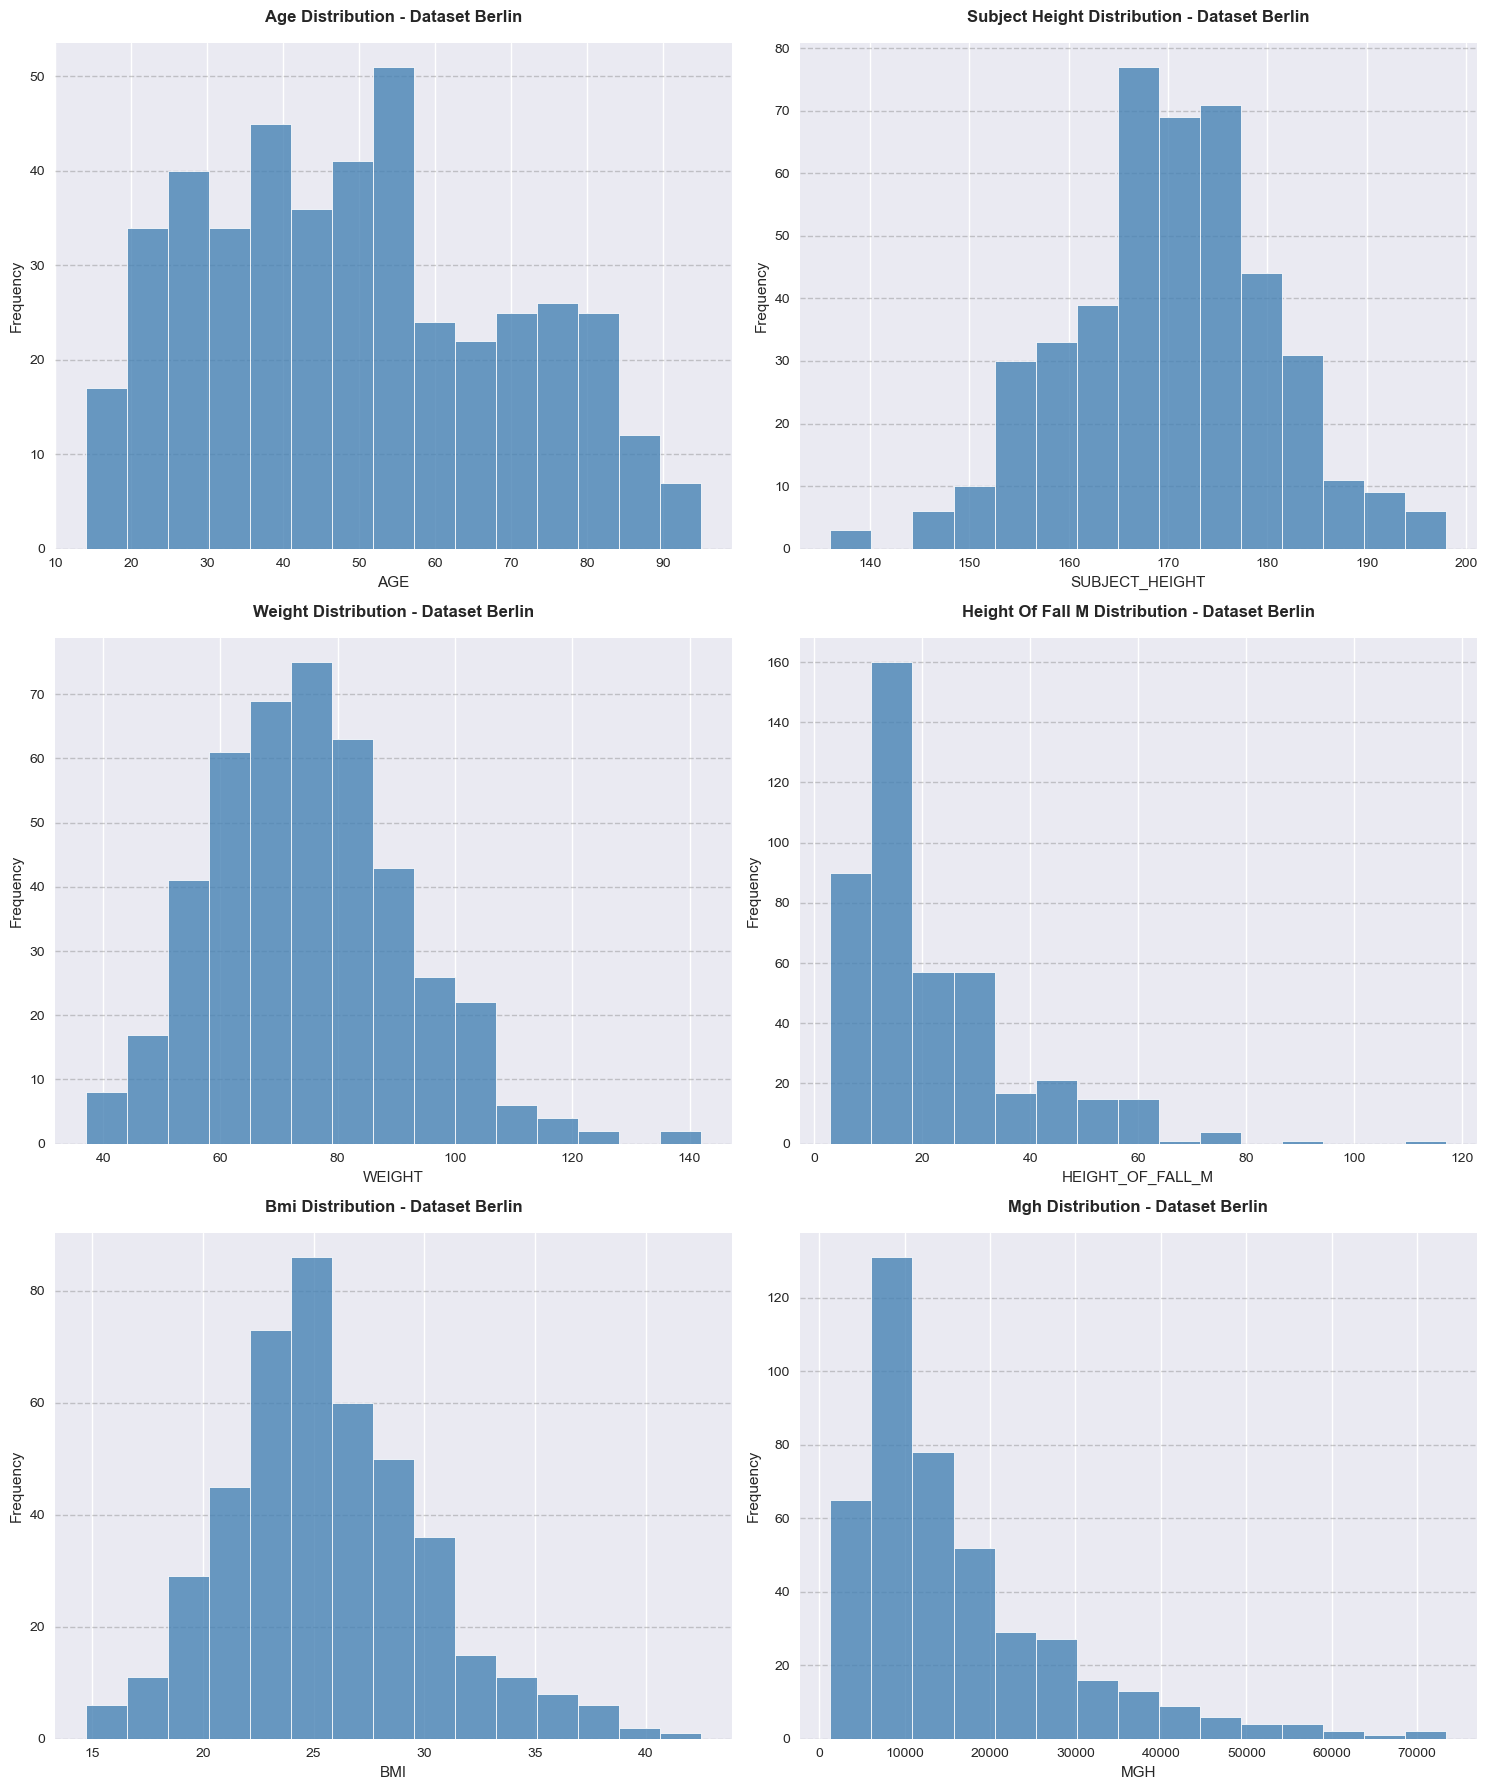

In [17]:
create_histogram_plots(df_berlin_without_null, hist_columns, 'Dataset Berlin')

In [18]:
df_berlin_without_null['height_of_fall_m'].describe()

count    439.000000
mean      22.174260
std       15.756976
min        3.000000
25%       12.000000
50%       15.000000
75%       29.250000
max      117.000000
Name: height_of_fall_m, dtype: float64

In [19]:
bins = [3,6, 9, 12,15,18,21,24,117]
height_binned = pd.cut(df_berlin_without_null['height_of_fall_m'], bins=bins, include_lowest=True)
height_freq = height_binned.value_counts().sort_index()

print(f"\nHeight frequency distribution for the Berlin dataset:")
for interval, count in height_freq.items():
    percentage = (count / len(df_berlin_without_null)) * 100
    print(f"  {interval}: {count} cases ({percentage:.1f}%)")


Height frequency distribution for the Berlin dataset:
  (2.999, 6.0]: 27 cases (6.2%)
  (6.0, 9.0]: 54 cases (12.3%)
  (9.0, 12.0]: 85 cases (19.4%)
  (12.0, 15.0]: 54 cases (12.3%)
  (15.0, 18.0]: 30 cases (6.8%)
  (18.0, 21.0]: 34 cases (7.7%)
  (21.0, 24.0]: 21 cases (4.8%)
  (24.0, 117.0]: 134 cases (30.5%)


### Rescale of the Injury Severity columns

Rescaling applied to injury severity columns:
- values equal or greater than 2 are rescaled to 1
- values lower than 2 are rescaled to 0

In [ ]:
injury_columns= ['neurocranium', 'viscerocranium',
       'telencephalon', 'cerebellum', 'brainstem', 'lungs',
       'larynx_bronchus', 'heart', 'aorta_thoracic', 'diaphragm',
       'liver', 'spleen', 'aorta_abdominal', 'kidneys', 'mesentery',
    'cervical_spine', 'thoracic_spine', 'lumbar_spine',
       'pelvis', 'skull_cervical_complex']

df_berlin_without_null_rescaled=df_berlin_without_null.copy()

for col in injury_columns:
    df_berlin_without_null_rescaled[col]=np.where(df_berlin_without_null_rescaled[col]>=2,1,0)

df_berlin_without_null_rescaled.head()

In [ ]:
body_region_injury={"head":['neurocranium', 'viscerocranium',
       'telencephalon', 'cerebellum', 'brainstem'] ,
                    "skeleton":['cervical_spine', 'thoracic_spine', 'lumbar_spine',
       'pelvis', 'skull_cervical_complex'], 
                    "thorax":['lungs',
       'larynx_bronchus', 'heart', 'aorta_thoracic', 'diaphragm'], 
                    "abdomen":['liver', 'spleen', 'aorta_abdominal', 'kidneys', 'mesentery']}

for key, items in body_region_injury.items():
    df_berlin_without_null_rescaled[key]=df_berlin_without_null_rescaled[items].sum(axis=1)

df_berlin_without_null_rescaled.head()

### Dropping columns: case_id, mgh

- case_id column represents unique identifier and is not needed for model training
- mgh is derived from height_of_fall_m and should be excluded to avoid data leakage

In [22]:
df_berlin_without_null_rescaled=df_berlin_without_null_rescaled.drop(columns=["case_id","mgh"])

### Save data after cleaning

In [23]:
# Save as .csv file
df_berlin_without_null_rescaled.to_csv("../data/processed/dati_berlino_cleaned.csv",index=False)

### Analyse predicted height of fall outliers 
Some of our experiments consists of training Kernel Ridge SVD model on a dataset where the column "height_of_fall" was capped at 18m.
In particular, we 3 experiments were done on the dataset: 1 with outliers removed setting IQR threshold at 1.5, 1 with outliers removed setting IQR threshold at 3.0, 1 with outliers not removed.
We analysed if the predicted height of fall by the model on the test data deviates too much from the real values. 
In this section, we are going to analyse the features of the predicted outliers. 

In [24]:
injury_features = ['neurocranium', 'viscerocranium', 'telencephalon', 'cerebellum', 'brainstem', 
                      'lungs', 'larynx_bronchus', 'heart', 'aorta_thoracic', 'diaphragm',
                      'liver', 'spleen', 'aorta_abdominal', 'kidneys', 'mesentery',
                      'cervical_spine', 'thoracic_spine', 'lumbar_spine', 'pelvis', 'skull_cervical_complex']
body_regions = ['head', 'thorax', 'abdomen', 'skeleton']
demographic_features = ['sex', 'age']
            

Case: height capped at 18m with outliers removed from the initial dataset with IQR threshold = 3.0

In [ ]:
df_predicted_height_outliers= pd.read_csv("../results/kernel_ridge_height18_outliers_removed_thresh3_random_seed_changed/outliers_predicted_y/kernel_ridge_robustscaler_svd2_dataset_1.csv")
print("Predicted Height Outliers:")
display(df_predicted_height_outliers)

In [ ]:
print("Records from initial dataset with 'height_of_fall_m' = 3")
df_berlin_height_3= df_berlin_without_null_rescaled[df_berlin_without_null_rescaled['height_of_fall_m']==3]
display(df_berlin_height_3)

In [27]:
injury_analysis = pd.DataFrame({
    'Total Number of Records': df_berlin_height_3[injury_features].count(),
    'Injury Rate (%)': (df_berlin_height_3[injury_features].sum() / len(df_berlin_height_3) * 100).round(1),
    'Cases with Injury': df_berlin_height_3[injury_features].sum(),
    'Cases without Injury': len(df_berlin_height_3) - df_berlin_height_3[injury_features].sum()
})

display(injury_analysis)

,Total Number of Records,Injury Rate (%),Cases with Injury,Cases without Injury
neurocranium,3,66.7,2,1
viscerocranium,3,0.0,0,3
telencephalon,3,0.0,0,3
cerebellum,3,0.0,0,3
brainstem,3,0.0,0,3
lungs,3,33.3,1,2
larynx_bronchus,3,33.3,1,2
heart,3,0.0,0,3
aorta_thoracic,3,0.0,0,3
diaphragm,3,0.0,0,3


In [28]:
df_berlin_height_3[demographic_features].describe()

,age
count,3.0
mean,63.0
std,35.156792
min,23.0
25%,50.0
50%,77.0
75%,83.0
max,89.0


In [29]:
display(df_berlin_height_3['age'].value_counts())

age
23    1
89    1
77    1
Name: count, dtype: Int64

In [30]:
display(df_berlin_height_3['sex'].value_counts())

sex
M    2
F    1
Name: count, dtype: Int64

Case: height capped at 18m with outliers not removed from the initial

In [ ]:
print("Predicted Height Outliers:")
df_predicted_height_outliers_with_outliers= pd.read_csv("../results/kernel_ridge_height18_with_outliers_random_seed_changed/outliers_predicted_y/kernel_ridge_robustscaler_svd1_dataset_1.csv")
display(df_predicted_height_outliers_with_outliers)

In [ ]:
print("Records from initial dataset with 'height_of_fall_m' = 9")
df_berlin_height_9= df_berlin_without_null_rescaled[df_berlin_without_null_rescaled['height_of_fall_m']==9]
df_berlin_height_9.head()

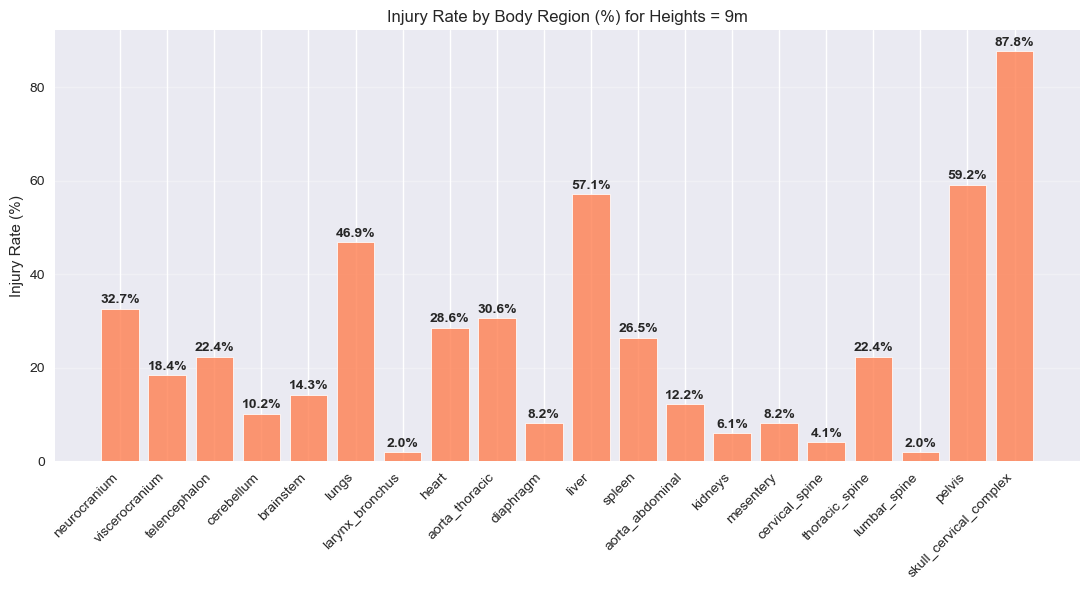

In [33]:
injury_analysis = pd.DataFrame({
    'Total Number of Records': df_berlin_height_9[injury_features].count(),
    'Injury Rate (%)': (df_berlin_height_9[injury_features].sum() / len(df_berlin_height_9) * 100).round(1),
    'Cases with Injury': df_berlin_height_9[injury_features].sum(),
    'Cases without Injury': len(df_berlin_height_9) - df_berlin_height_9[injury_features].sum()
})

plt.figure( figsize=(11, 6))

plt.bar(injury_analysis.index, injury_analysis['Injury Rate (%)'], 
               color='coral', alpha=0.8, edgecolor='white', linewidth=0.7)
plt.title('Injury Rate by Body Region (%) for Heights = 9m')
plt.ylabel('Injury Rate (%)')
plt.xticks(rotation=45, ha='right') 
plt.grid(axis='y', alpha=0.3)

for i, v in enumerate(injury_analysis['Injury Rate (%)']):
    plt.text(i, v + 0.5, f'{v}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


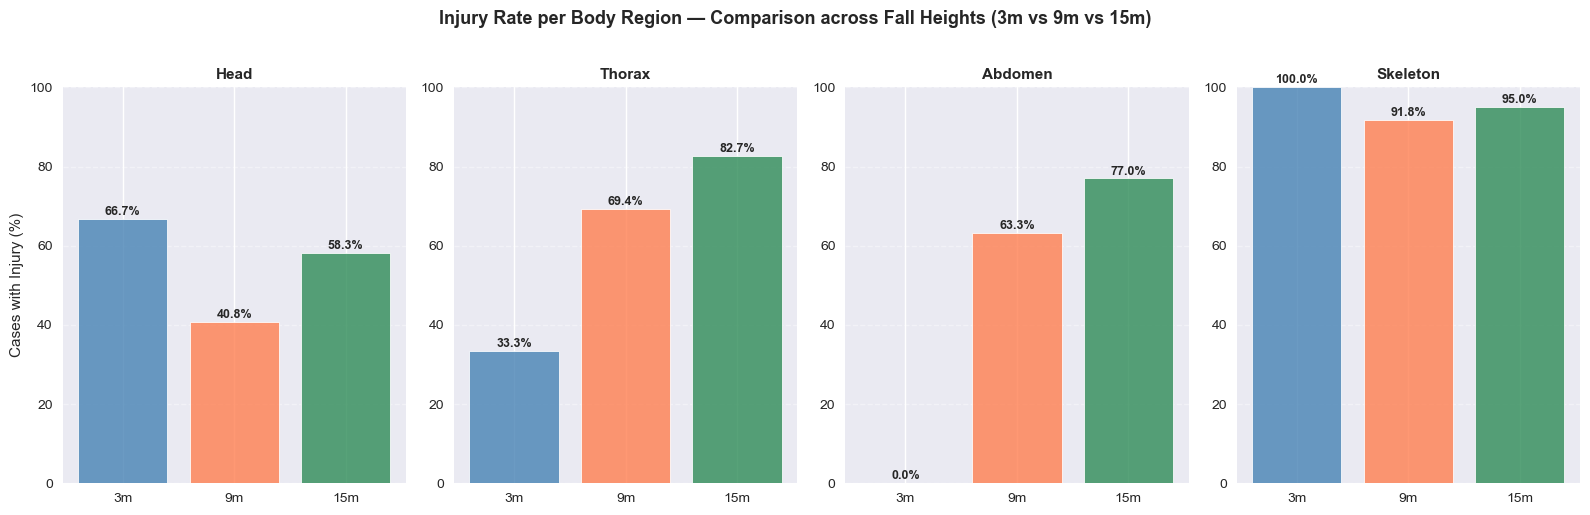

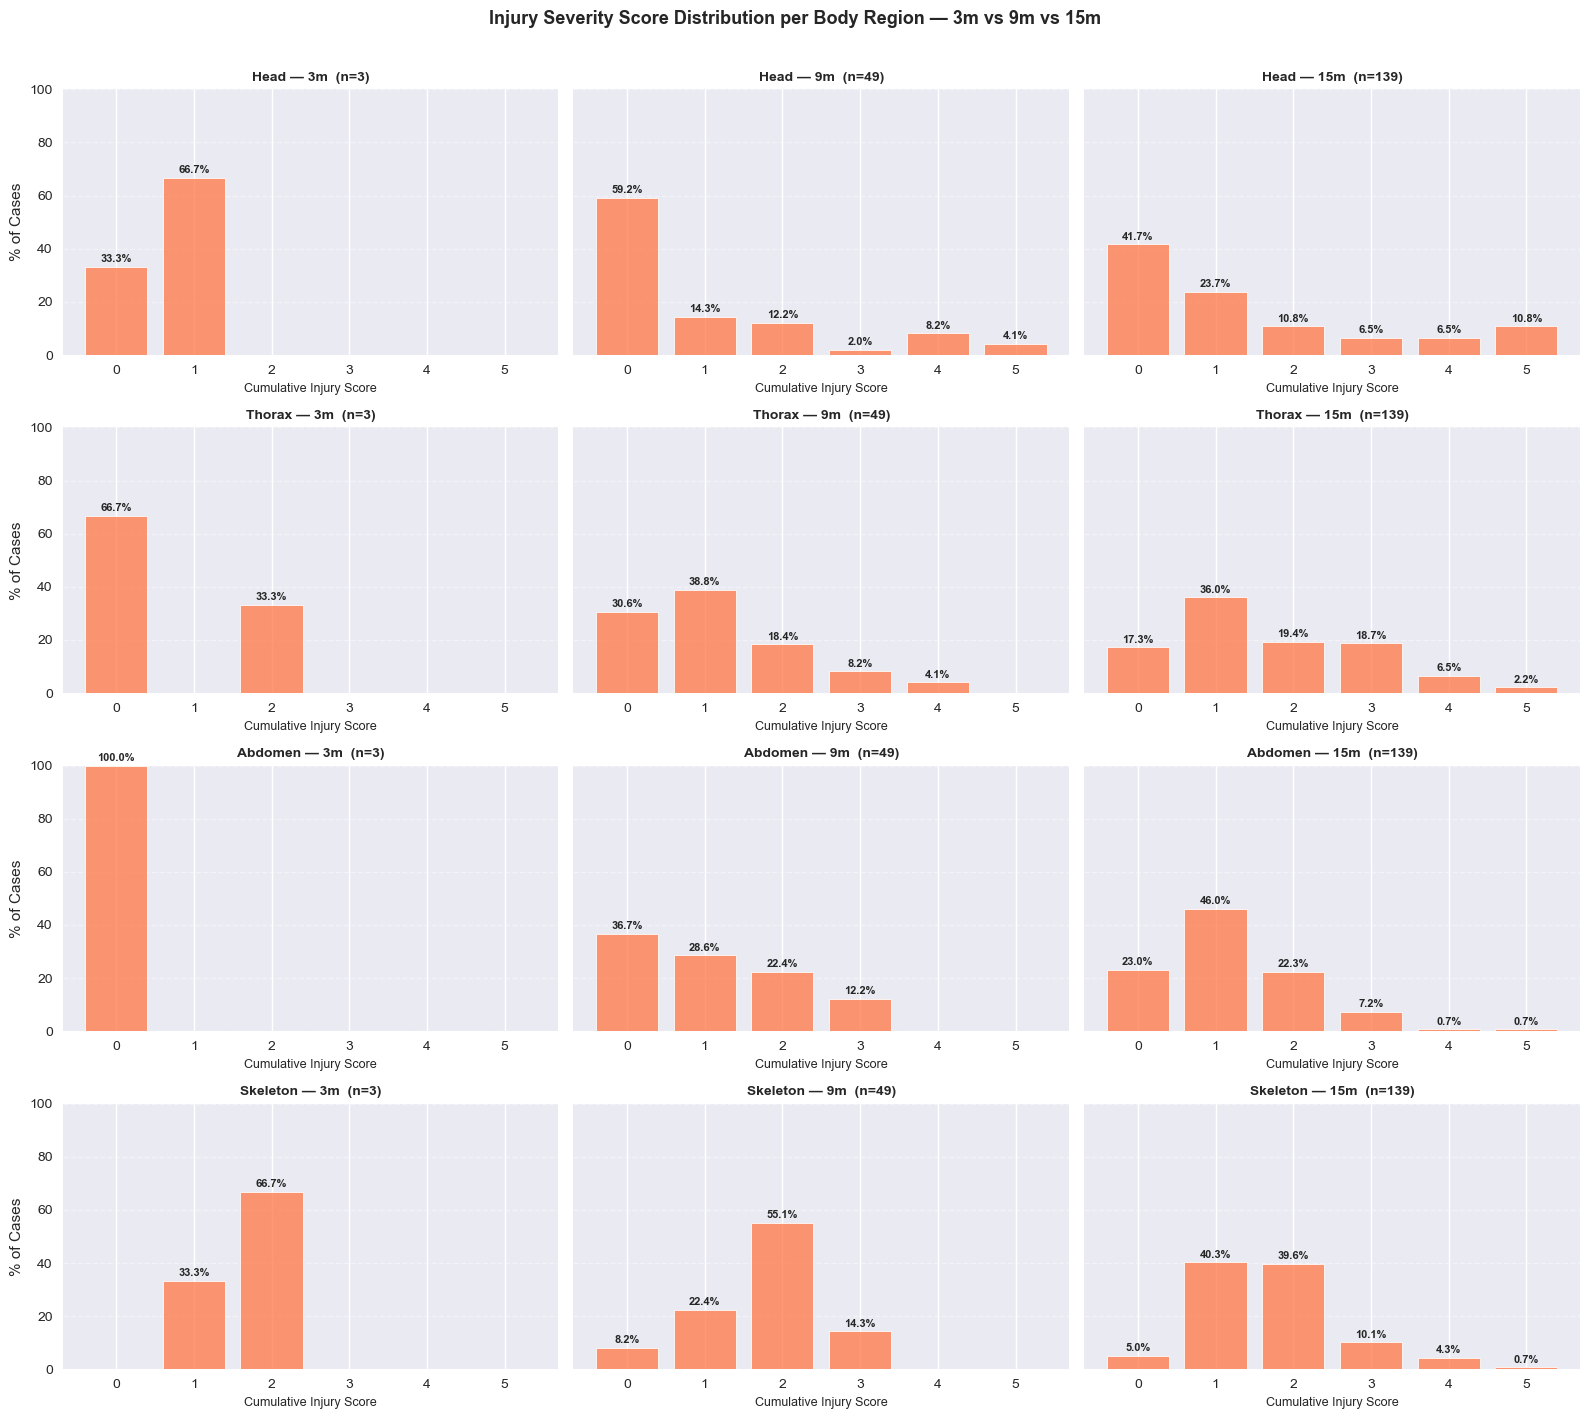

In [63]:
df_height_3 = df_berlin_without_null_rescaled[df_berlin_without_null_rescaled['height_of_fall_m'] == 3]
df_height_9 = df_berlin_without_null_rescaled[df_berlin_without_null_rescaled['height_of_fall_m'] == 9]
df_height_from_9_to_15 = df_berlin_without_null_rescaled[(df_berlin_without_null_rescaled['height_of_fall_m'] > 9) & (df_berlin_without_null_rescaled['height_of_fall_m'] <= 15)]

height_groups = {
    '3m': df_height_3,
    '9m': df_height_9,
    '15m': df_height_from_9_to_15
}

fig, axes = plt.subplots(1, len(body_regions), figsize=(16, 5))

for i, region in enumerate(body_regions):
    rates = {
        label: (df[region] > 0).sum() / len(df) * 100
        for label, df in height_groups.items()
    }
    axes[i].bar(rates.keys(), rates.values(), color=['steelblue', 'coral', 'seagreen'],
                alpha=0.8, edgecolor='white', linewidth=0.7)
    axes[i].set_title(f'{region.capitalize()}', fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Cases with Injury (%)' if i == 0 else '')
    axes[i].set_ylim(0, 100)
    axes[i].grid(axis='y', linestyle='--', alpha=0.4)
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)
    for j, (label, val) in enumerate(rates.items()):
        axes[i].text(j, val + 1, f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Injury Rate per Body Region — Comparison across Fall Heights (3m vs 9m vs 15m)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(len(body_regions), 3, figsize=(16, 14), sharey='row')

for i, region in enumerate(body_regions):
    for j, (label, df) in enumerate(height_groups.items()):
        total = len(df)
        
        value_counts = df[region].value_counts().reindex(range(0, 6), fill_value=0).sort_index()
        value_pcts = (value_counts / total * 100).round(1)

        axes[i, j].bar(value_pcts.index, value_pcts.values,
                       color='coral', alpha=0.8, edgecolor='white', linewidth=0.7)
        axes[i, j].set_title(f'{region.capitalize()} — {label}  (n={total})', fontsize=10, fontweight='bold')
        axes[i, j].set_xlabel('Cumulative Injury Score', fontsize=9)
        axes[i, j].set_ylabel('% of Cases' if j == 0 else '')
        axes[i, j].set_xticks(range(0, 6))
        axes[i, j].set_ylim(0, 100)
        axes[i, j].grid(axis='y', linestyle='--', alpha=0.4)
        axes[i, j].spines['top'].set_visible(False)
        axes[i, j].spines['right'].set_visible(False)

        for x, v in zip(value_pcts.index, value_pcts.values):
            if v > 0:
                axes[i, j].text(x, v + 1, f'{v:.1f}%',
                                ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.suptitle('Injury Severity Score Distribution per Body Region — 3m vs 9m vs 15m',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [36]:
df_berlin_height_9[demographic_features].describe()

,age
count,49.0
mean,53.346939
std,21.980627
min,15.0
25%,34.0
50%,55.0
75%,72.0
max,90.0


In [37]:
display(df_berlin_height_9['sex'].value_counts())

sex
M    30
F    19
Name: count, dtype: Int64

In [ ]:
display(df_berlin_height_9['age'].value_counts())

From the analysis emerges that all predicted heights representing outliers are overstimated by the models.

## Milan Data Analysis

In this section, the dataset with the records from Milan will be analyzed. The dataset is already divided into:
- test dataset with 50 records
- train dataset with 405 records

Columns: head , skeleton , thorax, abdomen  represent the cumulative sum of the injuries severity per body region. Severity can take value 0 or 1. 

In [39]:
df_milano_train=df_milano_train.rename(columns=column_mapping_milan_train)
df_milano_train['weight'] = df_milano_train['weight'].astype(str).str.replace(',', '.', regex=False)
df_milano_train['bmi'] = df_milano_train['bmi'].astype(str).str.replace(',', '.', regex=False)
df_milano_train['mgh'] = df_milano_train['mgh'].astype(str).str.replace(',', '.', regex=False)

In [40]:
df_milano_train=df_milano_train.astype(dtype=schema_milan)

In [ ]:
df_milano_train.head()

In [42]:
df_milano_test=df_milano_test.rename(columns=column_mapping_milan_test)
df_milano_test['weight'] = df_milano_test['weight'].astype(str).str.replace(',', '.', regex=False)
df_milano_test['bmi'] = df_milano_test['bmi'].astype(str).str.replace(',', '.', regex=False)
df_milano_test['mgh'] = df_milano_test['mgh'].astype(str).str.replace(',', '.', regex=False)

In [43]:
df_milano_test=df_milano_test.astype(dtype=schema_milan)

In [ ]:
df_milano_test.head()

In [ ]:
df_milano_train.nunique()

In [ ]:
df_milano_test.nunique()

In [47]:
df_milano_train[[ 'age', 'subject_height', 'weight', 'bmi',
       'height_of_fall_m', 'mgh']].describe().round(2).drop('count')

,age,subject_height,weight,bmi,height_of_fall_m,mgh
mean,55.55,166.07,70.47,25.40,15.29,10620.13
std,20.73,9.91,17.52,5.22,5.91,5420.37
min,13.0,140.00,29.60,12.68,6.00,1740.48
25%,38.0,160.00,58.00,21.91,9.00,6362.16
50%,57.0,166.00,67.00,24.69,15.00,10125.36
75%,74.0,173.00,81.00,27.85,21.00,13377.00
max,95.0,193.00,141.00,54.40,24.00,54978.00


In [48]:
df_milano_test[[ 'age', 'subject_height', 'weight', 'bmi',
       'height_of_fall_m', 'mgh']].describe().round(2).drop('count')

,age,subject_height,weight,bmi,height_of_fall_m,mgh
mean,55.3,165.40,68.57,24.89,15.24,10180.46
std,23.46,9.48,16.39,4.62,9.07,6258.64
min,15.0,145.00,42.60,17.17,3.00,1308.30
25%,34.0,160.00,57.12,21.31,9.25,6545.91
50%,57.5,165.00,68.00,24.73,12.00,8849.40
75%,71.75,170.75,75.85,27.12,18.00,12586.88
max,96.0,194.00,121.00,38.38,48.00,33539.52


In [ ]:
display(df_berlin['height_of_fall_m'].value_counts())

In [ ]:
categorical_columns=['sex','head', 'neurocranium', 'viscerocranium',
       'telencephalon', 'cerebellum', 'brainstem', 'thorax', 'lungs',
       'larynx_bronchus', 'heart', 'aorta_thoracic', 'diaphragm', 'abdomen',
       'liver', 'spleen', 'aorta_abdominal', 'kidneys', 'mesentery',
       'skeleton', 'cervical_spine', 'thoracic_spine', 'lumbar_spine',
       'pelvis', 'skull_cervical_complex']

for col in categorical_columns:
    print(f"\nColumn: {col}")
    print(f"Number of distinct values: {df_milano_train[col].value_counts().count()}")
    print(f"List of values and the number of times they appear in the dataset:")
    
    df_value_counts = df_milano_train[col].value_counts().reset_index()
    df_value_counts.columns = [col, 'count']
    
    display(
            df_value_counts.style.set_table_attributes(
                'style="display:block; max-height:300px; overflow-y:scroll;"'
            )
        )

In [51]:
complete_milan_dataset=pd.concat([df_milano_train,df_milano_test], ignore_index=True)
complete_milan_dataset['height_of_fall_m'].describe()

count    455.000000
mean      15.283516
std        6.320101
min        3.000000
25%        9.000000
50%       15.000000
75%       21.000000
max       48.000000
Name: height_of_fall_m, dtype: float64

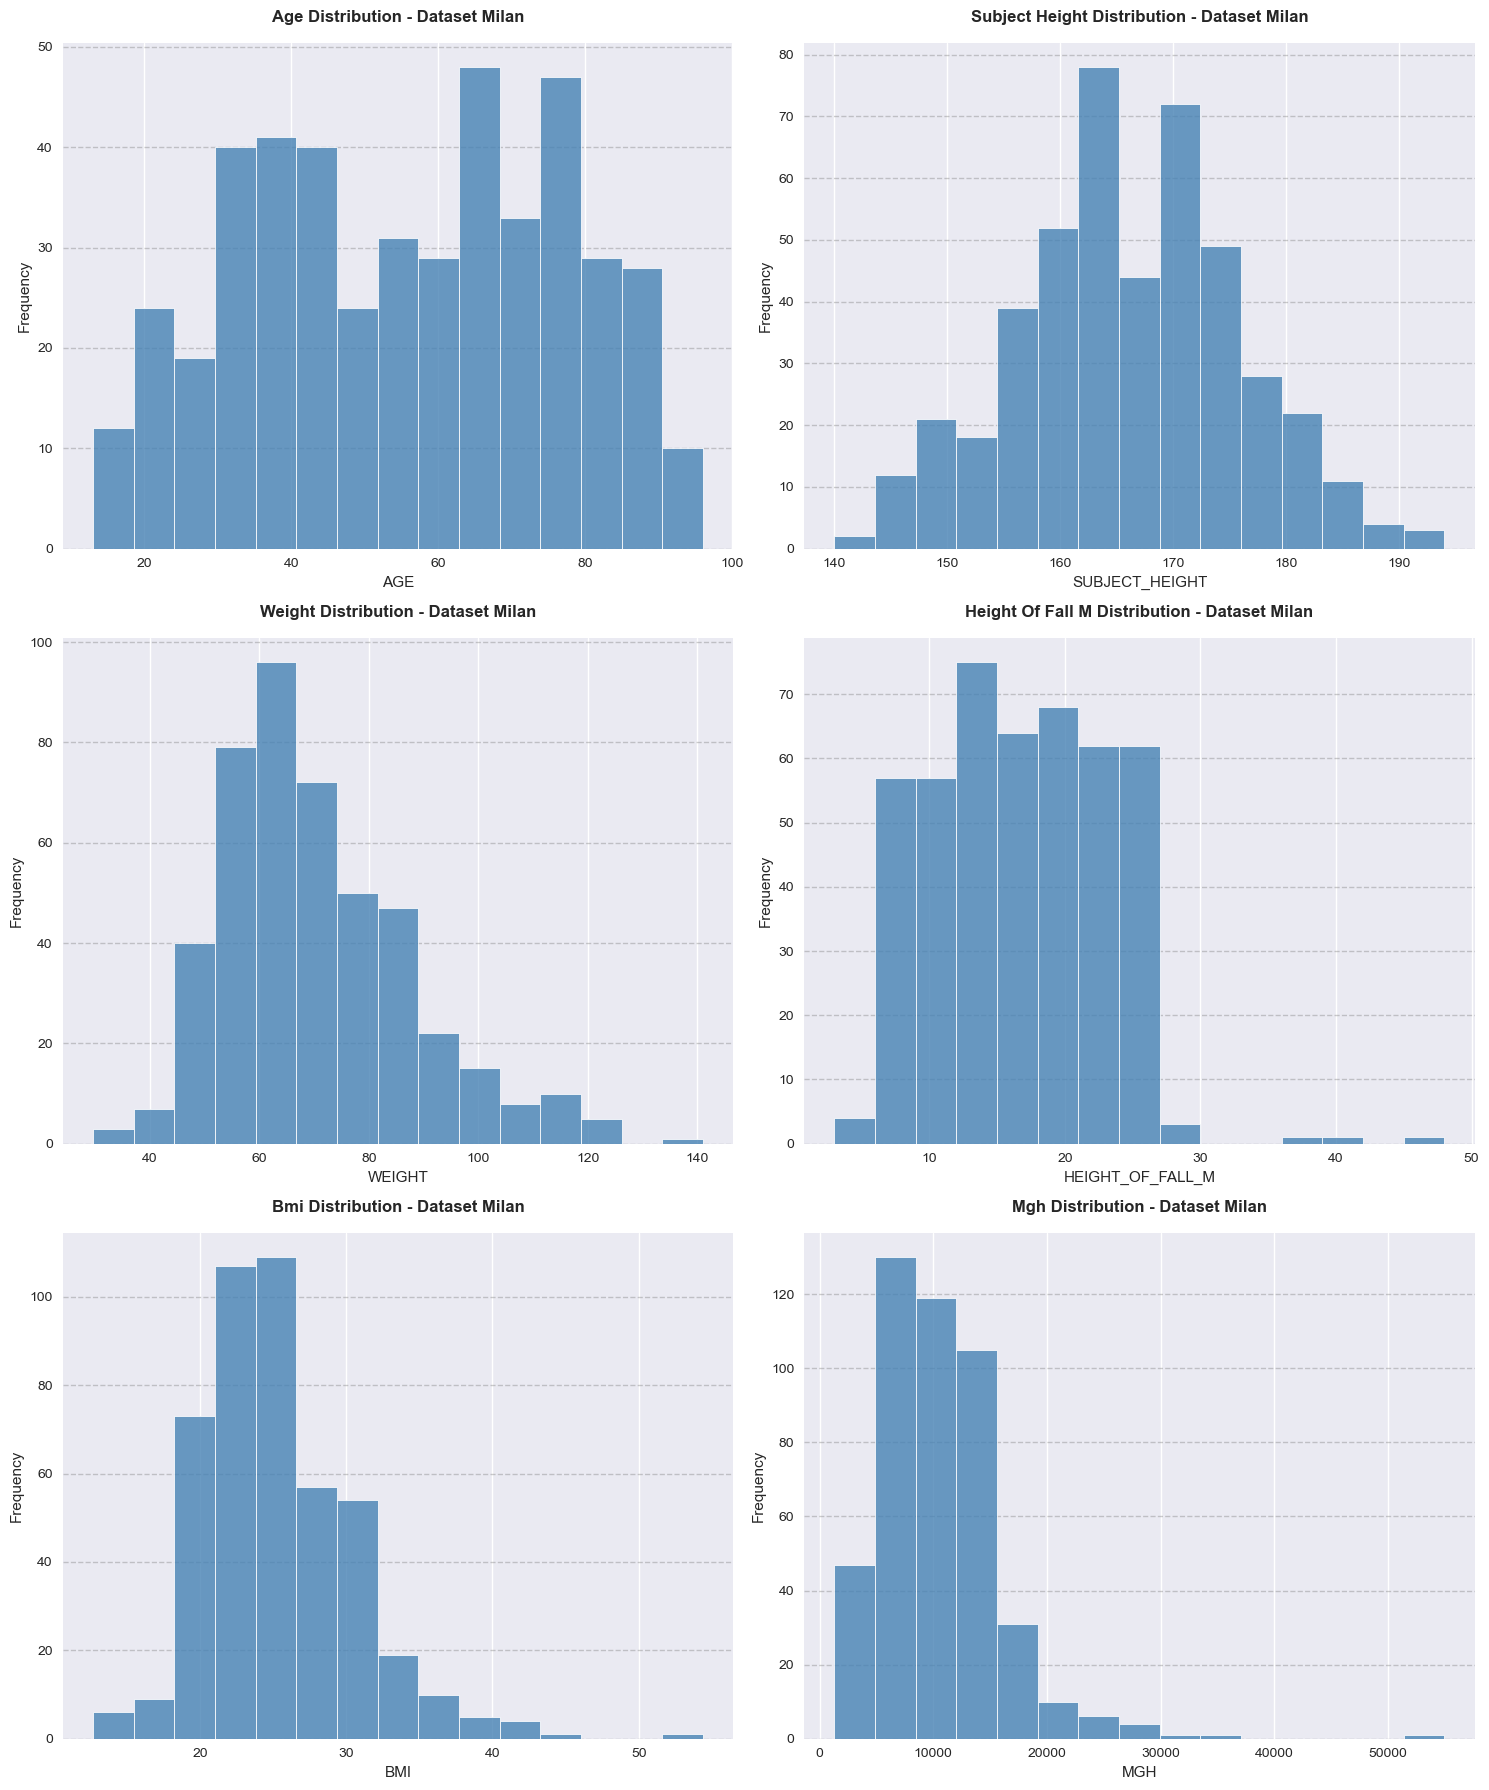

In [52]:
create_histogram_plots(complete_milan_dataset, hist_columns, 'Dataset Milan')

In [53]:
bins = [3,6, 9, 12,15,18,21,24,48]
height_binned = pd.cut(complete_milan_dataset['height_of_fall_m'], bins=bins, include_lowest=True)
height_freq = height_binned.value_counts().sort_index()

print(f"\nHeight frequency distribution for Milan dataset:")
for interval, count in height_freq.items():
    percentage = (count / len(complete_milan_dataset)) * 100
    print(f"  {interval}: {count} cases ({percentage:.1f}%)")


Height frequency distribution for Milan dataset:
  (2.999, 6.0]: 59 cases (13.0%)
  (6.0, 9.0]: 57 cases (12.5%)
  (9.0, 12.0]: 77 cases (16.9%)
  (12.0, 15.0]: 64 cases (14.1%)
  (15.0, 18.0]: 68 cases (14.9%)
  (18.0, 21.0]: 62 cases (13.6%)
  (21.0, 24.0]: 62 cases (13.6%)
  (24.0, 48.0]: 6 cases (1.3%)


In [54]:
bins = [3,6, 9, 12,15,18,21,24,48]
height_binned = pd.cut(df_milano_train['height_of_fall_m'], bins=bins, include_lowest=True)
height_freq = height_binned.value_counts().sort_index()

print(f"\nHeight frequency distribution for the train set:")
for interval, count in height_freq.items():
    percentage = (count / len(df_milano_train)) * 100
    print(f"  {interval}: {count} cases ({percentage:.1f}%)")

bins = [3,6, 9, 12,15,18,21,24,48]
height_binned = pd.cut(df_milano_test['height_of_fall_m'], bins=bins, include_lowest=True)
height_freq = height_binned.value_counts().sort_index()

print(f"\nHeight frequency distribution for the test set:")
for interval, count in height_freq.items():
    percentage = (count / len(df_milano_test)) * 100
    print(f"  {interval}: {count} cases ({percentage:.1f}%)")



Height frequency distribution for the train set:
  (2.999, 6.0]: 51 cases (12.6%)
  (6.0, 9.0]: 52 cases (12.8%)
  (9.0, 12.0]: 64 cases (15.8%)
  (12.0, 15.0]: 57 cases (14.1%)
  (15.0, 18.0]: 63 cases (15.6%)
  (18.0, 21.0]: 57 cases (14.1%)
  (21.0, 24.0]: 61 cases (15.1%)
  (24.0, 48.0]: 0 cases (0.0%)

Height frequency distribution for the test set:
  (2.999, 6.0]: 8 cases (16.0%)
  (6.0, 9.0]: 5 cases (10.0%)
  (9.0, 12.0]: 13 cases (26.0%)
  (12.0, 15.0]: 7 cases (14.0%)
  (15.0, 18.0]: 5 cases (10.0%)
  (18.0, 21.0]: 5 cases (10.0%)
  (21.0, 24.0]: 1 cases (2.0%)
  (24.0, 48.0]: 6 cases (12.0%)


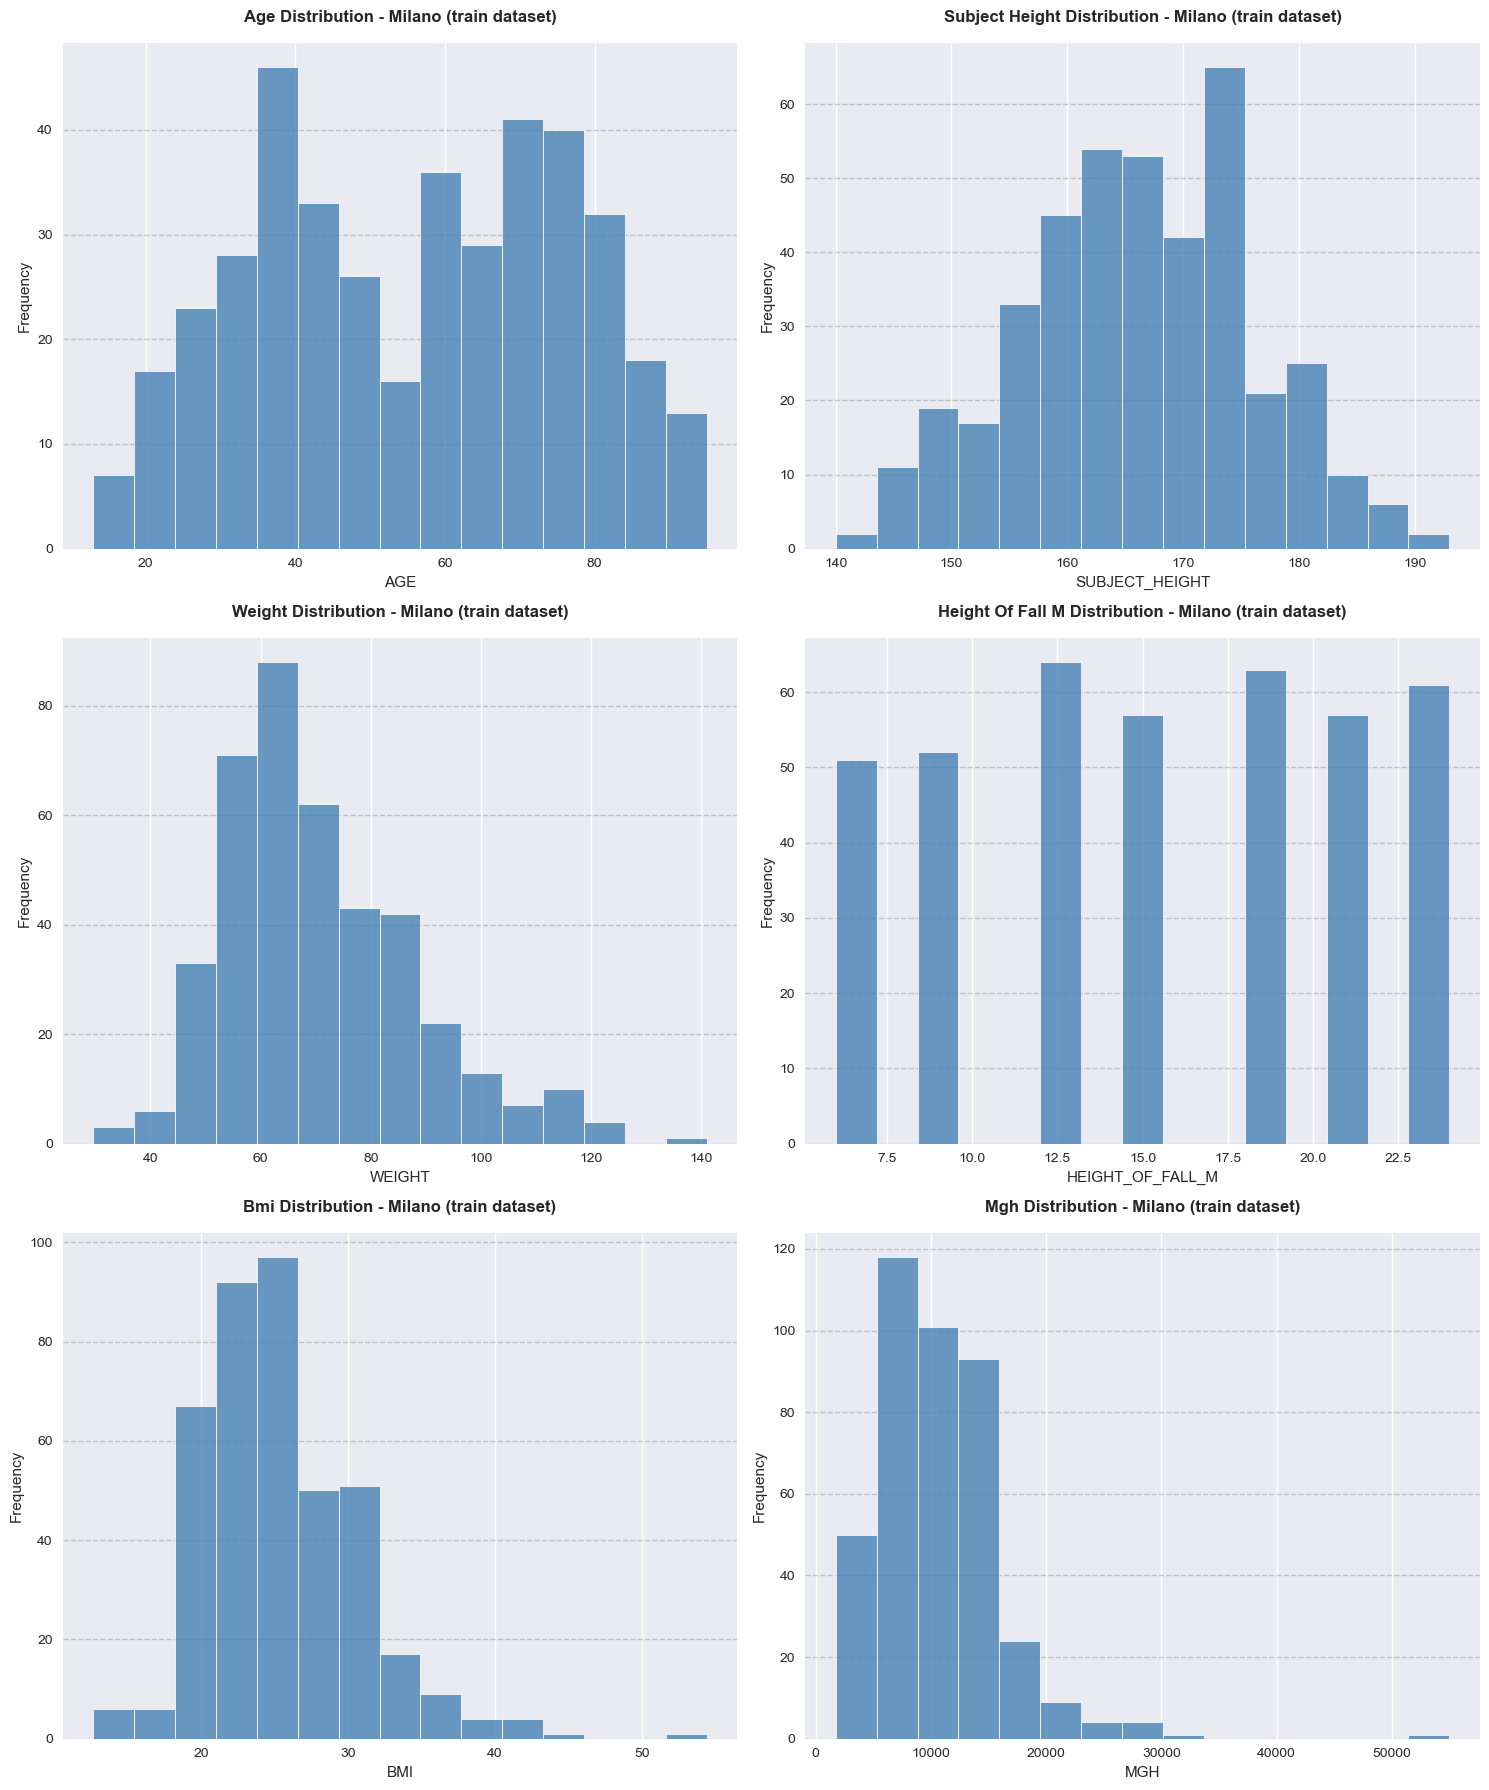

In [55]:
create_histogram_plots(df_milano_train, hist_columns, 'Milano (train dataset)')


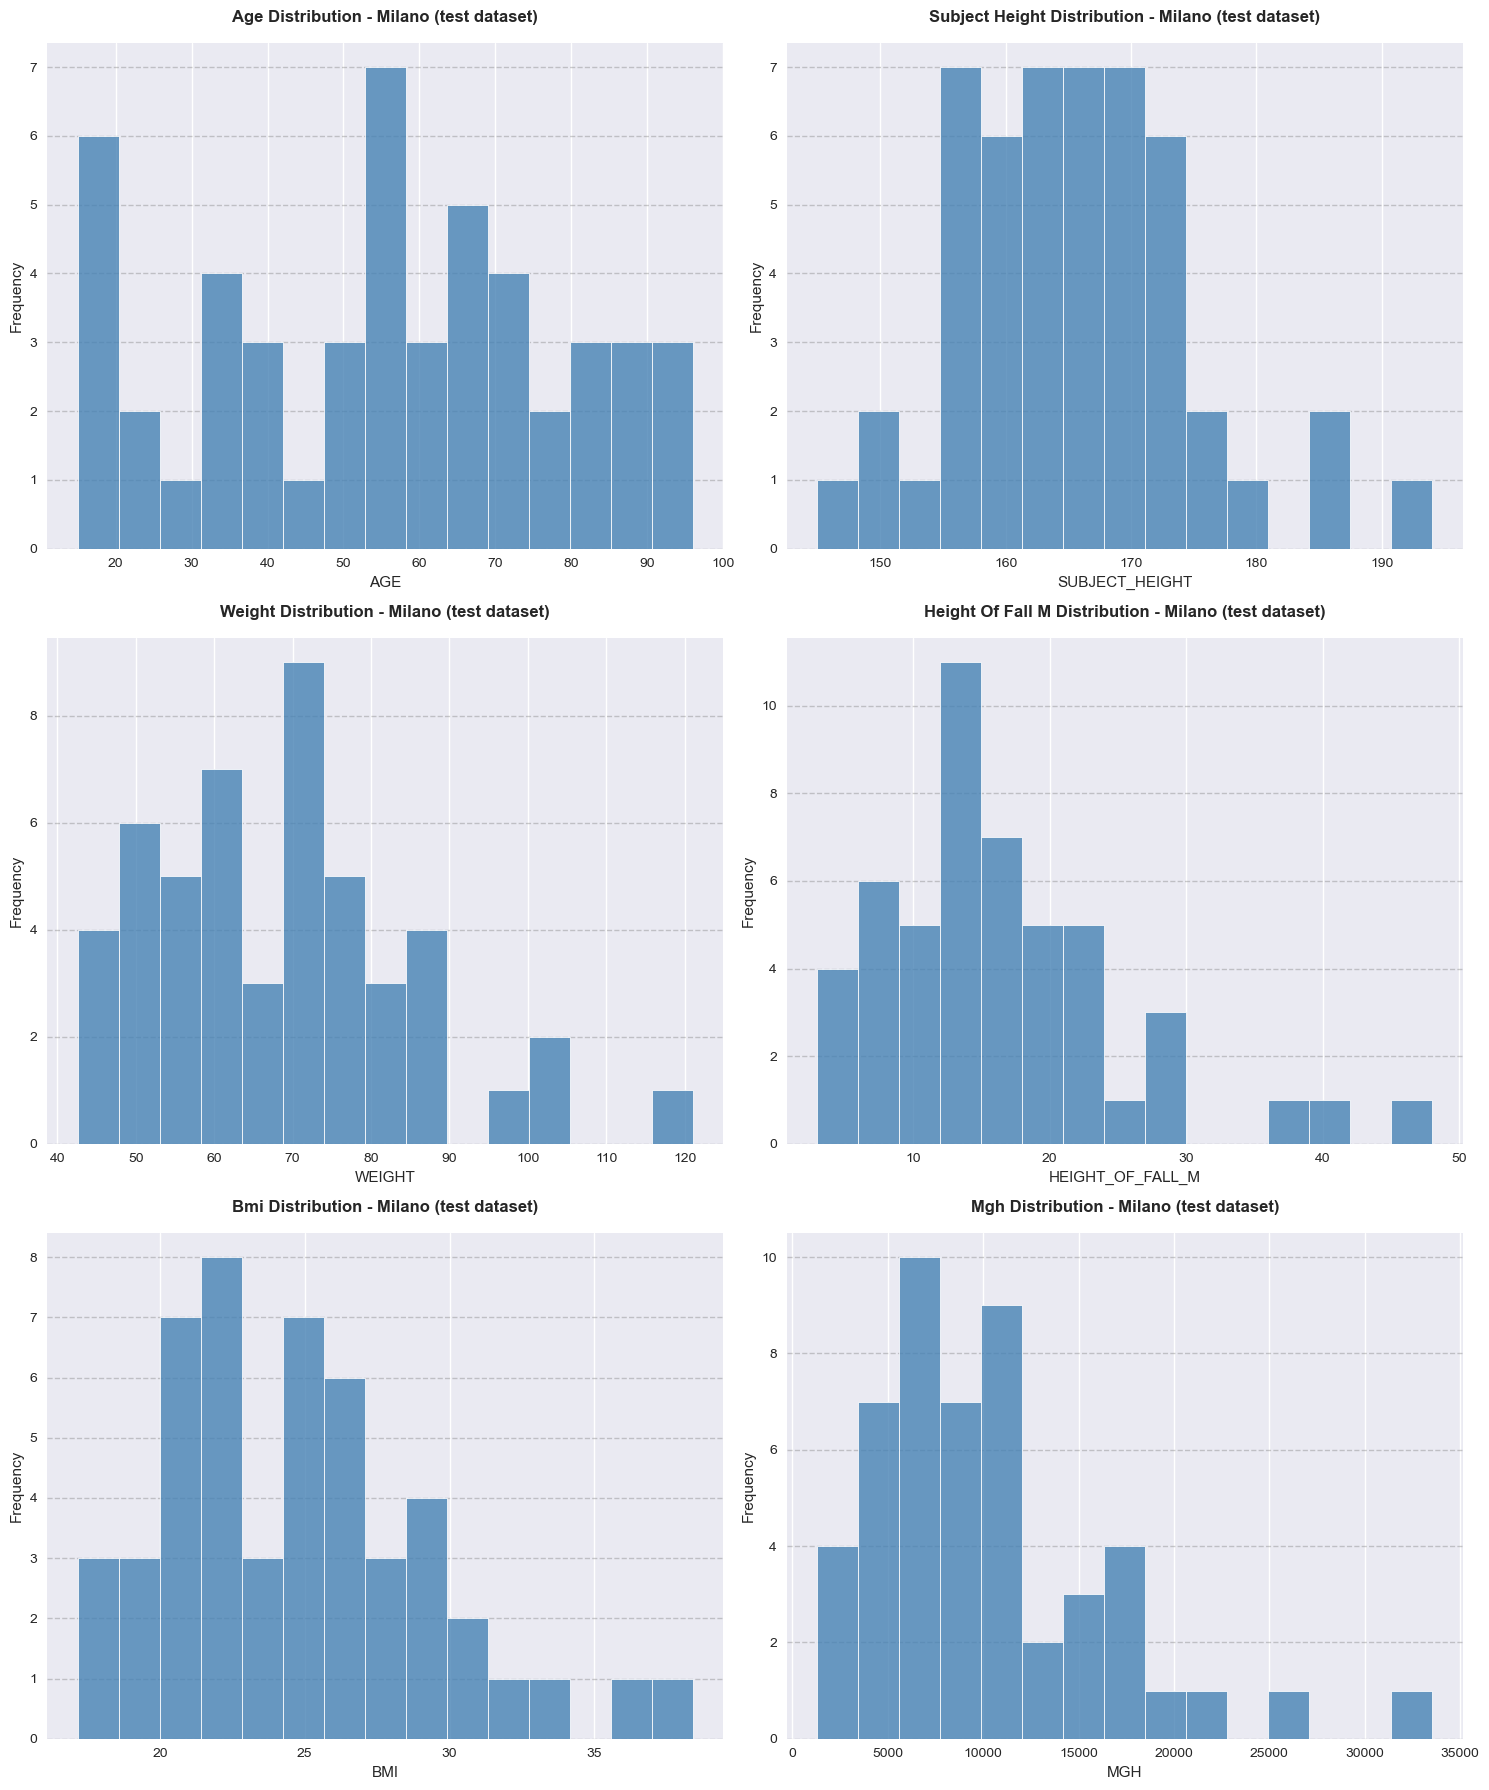

In [56]:
create_histogram_plots(df_milano_test, hist_columns, 'Milano (test dataset)')

### Drop Columns: case_id, mgh

In [57]:
df_milano_train=df_milano_train.drop(columns=['case_id','mgh'])
df_milano_test=df_milano_test.drop(columns=['case_id','mgh'])

### Save Data after Cleaning

In [58]:
df_milano_train.to_csv("../data/processed/dati_milano_train_cleaned.csv", index=False)
df_milano_test.to_csv("../data/processed/dati_milano_test_cleaned.csv", index=False)